# Section 1 -  Importation and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 1.1 Mounting Directory and Importing the Data

In [3]:
import sys
from pathlib import Path

# Define the Root (at SCANIA COMPONENT X)
PROJECT_ROOT = Path.cwd().parent

# Data Directory (Matches your "Data/Processed Data" folder exactly)
DATA_DIR = PROJECT_ROOT / "Data"


# Adding root to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Diagnostic Prints
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")


# Test if we can see the data file aka. if the path set-up is correct and the file exists
test_file = DATA_DIR / "train_operational_readouts.csv"
if test_file.exists():
    print(f"Path setup is correct. Found file: {test_file}")
else:
    raise FileNotFoundError(f"Missing expected file: {test_file}")

Project Root: c:\Users\Elias\Documents\SCANIA Component X
Data Source:  c:\Users\Elias\Documents\SCANIA Component X\Data
Path setup is correct. Found file: c:\Users\Elias\Documents\SCANIA Component X\Data\train_operational_readouts.csv


In [4]:
import importlib
import utils

importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Elias\\Documents\\SCANIA Component X\\utils\\__init__.py'>

### 1.2 Loading the Imported Data to Python

In [5]:
# Training data
train_readouts = pd.read_csv(DATA_DIR / 'train_operational_readouts.csv')
train_tte = pd.read_csv(DATA_DIR / 'train_tte.csv')
train_specs = pd.read_csv(DATA_DIR / 'train_specifications.csv')

# Validation data
val_readouts = pd.read_csv(DATA_DIR / 'validation_operational_readouts.csv')
val_labels = pd.read_csv(DATA_DIR / 'validation_labels.csv')
val_specs = pd.read_csv(DATA_DIR / 'validation_specifications.csv')

# Test data
test_readouts = pd.read_csv(DATA_DIR / 'test_operational_readouts.csv')
test_labels = pd.read_csv(DATA_DIR / 'test_labels.csv')
test_specs = pd.read_csv(DATA_DIR / 'test_specifications.csv')

In [6]:
# Check the shape for each dataset
print("=== Dataset Shapes ===")
print(f"Train readouts: {train_readouts.shape}")
print(f"Train TTE:      {train_tte.shape}")
print(f"Train specs:    {train_specs.shape}")
print(f"\nVal readouts:   {val_readouts.shape}")
print(f"Val labels:     {val_labels.shape}")
print(f"Val specs:      {val_specs.shape}")
print(f"\nTest readouts:  {test_readouts.shape}")
print(f"Test labels:    {test_labels.shape}")
print(f"Test specs:     {test_specs.shape}")

# Checking the readouts for the first 5 rows.
print("=== Train Readouts (first 5 rows) ===")
print(train_readouts.head())

print("\n=== Train TTE (first 5 rows) ===")
print(train_tte.head())

print("\n=== Val Labels (first 5 rows) ===")
print(val_labels.head())

=== Dataset Shapes ===
Train readouts: (1122452, 107)
Train TTE:      (23550, 3)
Train specs:    (23550, 9)

Val readouts:   (196227, 107)
Val labels:     (5046, 2)
Val specs:      (5046, 9)

Test readouts:  (198140, 107)
Test labels:    (5045, 2)
Test specs:     (5045, 9)
=== Train Readouts (first 5 rows) ===
   vehicle_id  time_step     171_0    666_0       427_0   837_0   167_0  \
0           0       11.2  167985.0  10787.0   7413813.0  2296.0  4110.0   
1           0       11.4  167985.0  10787.0   7413813.0  2296.0  4111.0   
2           0       19.6  331635.0  14525.0  13683604.0  2600.0     NaN   
3           0       20.2  354975.0  15015.0  14540449.0  2616.0     NaN   
4           0       21.0  365550.0  15295.0  14966985.0  2720.0     NaN   

       167_1      167_2     167_3  ...    397_26   397_27  397_28  397_29  \
0  1296420.0  1628265.0  630345.0  ...   95728.0  15609.0  1984.0     8.0   
1  1302855.0  1628265.0  630345.0  ...   95729.0  15610.0  1984.0     8.0   
2     

# Section 2 -Exploratory Data Analysis

### 2.1 Class Distribution

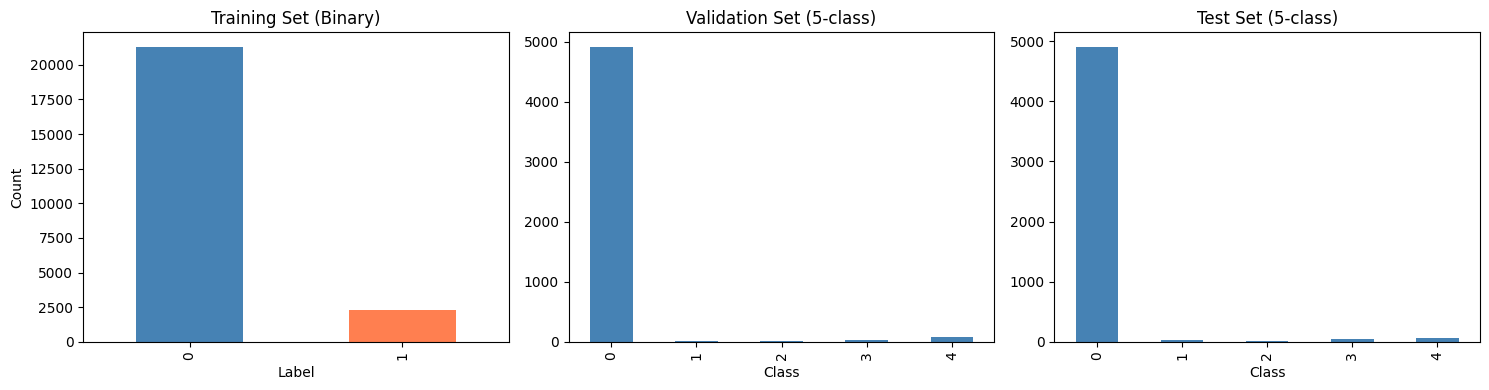

=== Missing Values (%) ===
291_10    0.857765
291_9     0.857765
291_8     0.857765
291_2     0.857765
291_4     0.857765
            ...   
272_3     0.046773
666_0     0.003564
837_0     0.003475
835_0     0.003475
309_0     0.003029
Length: 104, dtype: float64

Max missing: 0.86%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training: binary
train_tte['in_study_repair'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Training Set (Binary)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

# Validation: 5-class
val_labels['class_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Validation Set (5-class)')
axes[1].set_xlabel('Class')

# Test: 5-class
test_labels['class_label'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Test Set (5-class)')
axes[2].set_xlabel('Class')

plt.tight_layout()
plt.show()

# Missing value percentage per column
missing_pct = train_readouts.isnull().mean() * 100
print("=== Missing Values (%) ===")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))
print(f"\nMax missing: {missing_pct.max():.2f}%")

### 2.2 Readouts per Vehicles

=== Readouts per Vehicle ===
count    23550.000000
mean        47.662505
std         27.406028
min          5.000000
25%         28.000000
50%         43.000000
75%         64.000000
max        303.000000
dtype: float64


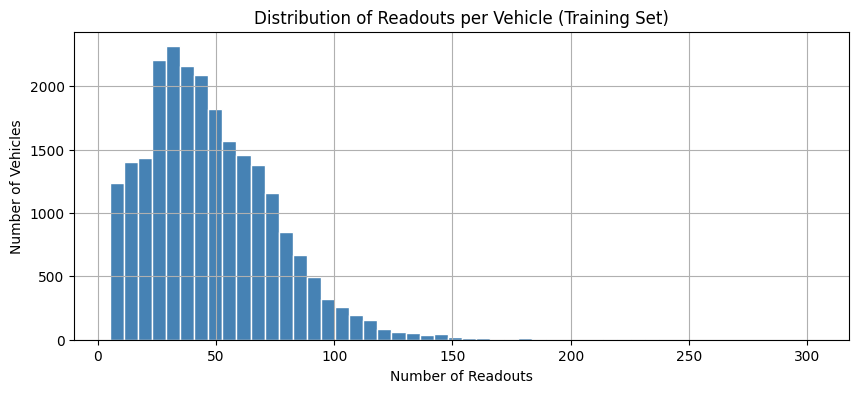

In [8]:
readouts_per_vehicle = train_readouts.groupby('vehicle_id').size()

print("=== Readouts per Vehicle ===")
print(readouts_per_vehicle.describe())

fig, ax = plt.subplots(figsize=(10, 4))
readouts_per_vehicle.hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Readouts per Vehicle (Training Set)')
ax.set_xlabel('Number of Readouts')
ax.set_ylabel('Number of Vehicles')
plt.show()

In [9]:
# Verify cumulative column classification on raw data
raw_numeric = [c for c in train_readouts.columns if c not in ['vehicle_id', 'time_step']]
cum_cols_check = utils.get_cumulative_cols(train_readouts, raw_numeric)

print(f"=== Cumulative Column Classification ===")
print(f"Total numeric features:           {len(raw_numeric)}")
print(f"Cumulative (will be differenced): {len(cum_cols_check)}")
print(f"Not cumulative (kept as-is):      {len(raw_numeric) - len(cum_cols_check)}")

# Checks if the classified columns are genuinely monotonically increasing
print(f"\n=== Spot Check: Are Diffs Always Non-Negative? ===")
for col in ['171_0', '427_0', '397_0', '397_2', '167_0']:
    diffs = train_readouts.groupby('vehicle_id')[col].diff().dropna()
    pct_positive = (diffs > 0).mean()
    pct_negative = (diffs < 0).mean()
    print(f"{col}: {pct_positive*100:.1f}% increasing, {pct_negative*100:.1f}% decreasing")

Analyzing cumulative features with threshold 0.95...
Cumulative features: ['171_0', '666_0', '427_0', '837_0', '167_0', '167_1', '167_2', '167_3', '167_4', '167_5', '167_6', '167_7', '167_8', '167_9', '309_0', '272_0', '272_1', '272_2', '272_3', '272_4', '272_5', '272_6', '272_7', '272_8', '272_9', '835_0', '370_0', '291_0', '291_1', '291_2', '291_3', '291_4', '291_5', '291_6', '291_7', '291_8', '291_9', '291_10', '158_0', '158_1', '158_2', '158_3', '158_4', '158_5', '158_6', '158_7', '158_8', '158_9', '100_0', '459_0', '459_1', '459_2', '459_3', '459_4', '459_5', '459_6', '459_7', '459_8', '459_9', '459_10', '459_11', '459_12', '459_13', '459_14', '459_15', '459_16', '459_17', '459_18', '459_19', '397_0', '397_1', '397_2', '397_3', '397_4', '397_5', '397_6', '397_7', '397_8', '397_9', '397_10', '397_11', '397_12', '397_13', '397_14', '397_15', '397_16', '397_17', '397_18', '397_19', '397_20', '397_21', '397_22', '397_23', '397_24', '397_25', '397_26', '397_27', '397_28', '397_29', '39

### 2.3 Distribution of Readouts Per Vehicle  

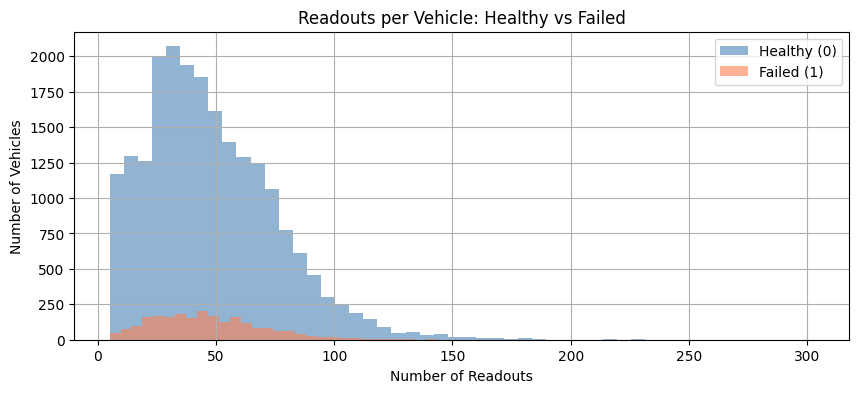

In [10]:
merged = train_readouts.groupby('vehicle_id').size().reset_index(name='num_readouts')
merged = merged.merge(train_tte[['vehicle_id', 'in_study_repair']], on='vehicle_id')

fig, ax = plt.subplots(figsize=(10, 4))
merged[merged['in_study_repair'] == 0]['num_readouts'].hist(bins=50, ax=ax, alpha=0.6, label='Healthy (0)', color='steelblue')
merged[merged['in_study_repair'] == 1]['num_readouts'].hist(bins=50, ax=ax, alpha=0.6, label='Failed (1)', color='coral')
ax.set_title('Readouts per Vehicle: Healthy vs Failed')
ax.set_xlabel('Number of Readouts')
ax.set_ylabel('Number of Vehicles')
ax.legend()
plt.show()

### 2.4 Comparison of Single Feature Evolution Over Time - Healthy vs Failed

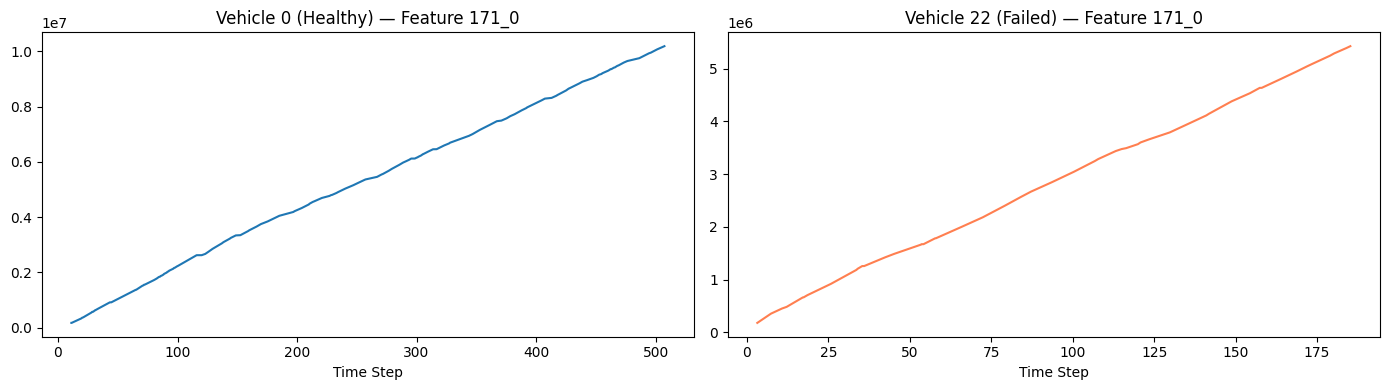

In [11]:
# How a single feature evolve over time for a healthy vs failed vehicle
healthy_id = train_tte[train_tte['in_study_repair'] == 0]['vehicle_id'].iloc[0]
failed_id = train_tte[train_tte['in_study_repair'] == 1]['vehicle_id'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

healthy_data = train_readouts[train_readouts['vehicle_id'] == healthy_id]
failed_data = train_readouts[train_readouts['vehicle_id'] == failed_id]

axes[0].plot(healthy_data['time_step'], healthy_data['171_0'])
axes[0].set_title(f'Vehicle {healthy_id} (Healthy) — Feature 171_0')
axes[0].set_xlabel('Time Step')

axes[1].plot(failed_data['time_step'], failed_data['171_0'], color='coral')
axes[1].set_title(f'Vehicle {failed_id} (Failed) — Feature 171_0')
axes[1].set_xlabel('Time Step')

plt.tight_layout()
plt.show()

### 2.5 Conclusions

The EDA reveals a dataset that is relativley clean, but structurally challenging. As has been noted in the paper on this dataset, it is evidently severly imbalanced. Failures are rare event and make up around 10% of the training data and under 3% of the validation and test data.

Moerover, we observe that the healthy and failed vehicles follow similar readout length distributions, which means we cannot rely on sequence length as a shortcut for prediction. Instead, we must use the actual sensor patterns within the sequence to train the model.

Practically, the data requieres true key transformations before modelling. Sequences need to be standardized for the temporal models and the cumultive features need to be vonverted to delras to capute meaningful change patterns not absolute values. Missing data is negliable, however will be imputed with a simple imputator.


# Section  3 - Preprocessing

## 3.1 - Data Preparation


### 3.1.1 - Merging Data and Binirizing Target

Val and test labels use a 5-class systemm where 0 = healthy, 1-4 = Different failures with different costs. We use binirize and use a class > 0 = failure, collapsing all failure classes into one positive label.

In [12]:
# ----------------------------------------------------------------------
# Label construction
# ----------------------------------------------------------------------
# CRITICAL: the raw `in_study_repair` flag is vehicle-level — it says whether
# a vehicle was *ever* repaired during the study, not whether it is failing
# at any given timestep. Broadcasting that flag to every readout would tell
# the model that healthy early-life readings of failed vehicles are
# "failures" — which they are not.
#
# Instead, label each readout based on its time-to-event:
#   For failed vehicles:  label = 1 if (T_fail - time_step) <= HORIZON, else 0
#   For healthy vehicles: label = 0 always
#
# This matches val/test, where positive class means "failure imminent within
# the prediction window," not "this vehicle ever failed."

HORIZON = 48  # time steps before failure that count as positive

# ---- TRAIN ----
# Merge in failure time T for failed vehicles
train_data = train_readouts.merge(
    train_tte[['vehicle_id', 'length_of_study_time_step', 'in_study_repair']],
    on='vehicle_id'
)

# Time-to-failure for failed vehicles; healthy vehicles get NaN (will become 0)
train_data['time_to_failure'] = np.where(
    train_data['in_study_repair'] == 1,
    train_data['length_of_study_time_step'] - train_data['time_step'],
    np.nan
)

# Label = 1 only if vehicle fails AND we're within the horizon window
train_data['label'] = (
    (train_data['in_study_repair'] == 1) &
    (train_data['time_to_failure'] <= HORIZON) &
    (train_data['time_to_failure'] >= 0)  # safety: drop any post-failure readouts
).astype(int)

# Drop helper columns
train_data = train_data.drop(columns=['length_of_study_time_step', 'in_study_repair', 'time_to_failure'])

failed_ids = set(train_tte[train_tte['in_study_repair']==1]['vehicle_id'])
positive_ids = set(train_data[train_data['label']==1]['vehicle_id'])
missing_failed = failed_ids - positive_ids

if missing_failed:
    print(f"Dropping {len(missing_failed)} failed vehicles with no readouts near failure")
    train_data = train_data[~train_data['vehicle_id'].isin(missing_failed)].copy()
    print(f"Train shape after drop: {train_data.shape}")

# ---- VAL & TEST ---- (unchanged — labels are already per-vehicle here)
val_labels['binary_label'] = (val_labels['class_label'] > 0).astype(int)
val_data = val_readouts.merge(val_labels[['vehicle_id', 'binary_label']], on='vehicle_id')
val_data = val_data.rename(columns={'binary_label': 'label'}).copy()

test_labels['binary_label'] = (test_labels['class_label'] > 0).astype(int)
test_data = test_readouts.merge(test_labels[['vehicle_id', 'binary_label']], on='vehicle_id')
test_data = test_data.rename(columns={'binary_label': 'label'}).copy()

train_data = train_data.copy()

C:\Users\Elias\AppData\Local\Temp\ipykernel_28468\4059822232.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_data['time_to_failure'] = np.where(
C:\Users\Elias\AppData\Local\Temp\ipykernel_28468\4059822232.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_data['label'] = (


Dropping 10 failed vehicles with no readouts near failure
Train shape after drop: (1122267, 108)


In [13]:
print(f"train_data shape: {train_data.shape}")
print(f"val_data shape:   {val_data.shape}")
print(f"test_data shape:  {test_data.shape}")

print(f"\n=== Train label distribution (per readout) ===")
print(train_data['label'].value_counts())
print(f"Positive rate: {train_data['label'].mean():.4f}")

print(f"\n=== Train: vehicles with at least one positive readout ===")
n_pos_vehicles = train_data[train_data['label']==1]['vehicle_id'].nunique()
n_failed_vehicles = (train_tte['in_study_repair']==1).sum()
print(f"Vehicles with positive readouts: {n_pos_vehicles}")
print(f"Total failed vehicles in tte:    {n_failed_vehicles}")
# These should be roughly equal — every failed vehicle should have at least
# HORIZON timesteps before its failure, contributing some positive readouts.

print(f"\n=== Avg positive readouts per failed vehicle ===")
positives_per_failed = train_data[train_data['label']==1].groupby('vehicle_id').size()
print(positives_per_failed.describe())
# Expected: most failed vehicles contribute up to HORIZON+1 positive readouts.

print(f"\n=== Val label distribution ===")
print(val_data.groupby('vehicle_id')['label'].first().value_counts())

train_data shape: (1122267, 108)
val_data shape:   (196227, 108)
test_data shape:  (198140, 108)

=== Train label distribution (per readout) ===
label
0    1096527
1      25740
Name: count, dtype: int64
Positive rate: 0.0229

=== Train: vehicles with at least one positive readout ===
Vehicles with positive readouts: 2262
Total failed vehicles in tte:    2272

=== Avg positive readouts per failed vehicle ===
count    2262.000000
mean       11.379310
std         4.873388
min         1.000000
25%         9.000000
50%        11.000000
75%        14.000000
max        39.000000
dtype: float64

=== Val label distribution ===
label
0    4910
1     136
Name: count, dtype: int64


## 3.2 - Feature Engineering

### 3.3.2 - Data Imputation  

In [14]:
# ----------------------------------------------------------------------
# Imputation
# ----------------------------------------------------------------------
# Strategy:
#   1. Sort each split by (vehicle_id, time_step) so per-group fills are temporal.
#   2. Identify cumulative columns ONCE on raw train data; this same list will
#      be reused in the differencing cell (Cell 32) — do not recompute there.
#   3. For cumulative columns: backfill leading NaNs *within each vehicle*.
#      This is not cross-split leakage (we're not using train→val info) and not
#      look-ahead leakage in the modeling sense (we predict on full sequences,
#      not next-step). It avoids the artifact where a global-median fill on a
#      monotonic counter creates a spurious large negative delta at the
#      imputed→real boundary.
#   4. Forward-fill all features per vehicle (preserves temporal causality).
#   5. Any remaining NaNs (vehicles with all-NaN columns, or true leading NaNs
#      for non-cumulative features) get filled with the *train* median.

# 1. Sort
train_data = train_data.sort_values(['vehicle_id', 'time_step'])
val_data   = val_data.sort_values(['vehicle_id', 'time_step'])
test_data  = test_data.sort_values(['vehicle_id', 'time_step'])

# 2. Identify feature columns (exclude ids, labels, non-numerics)
non_numeric_cols   = [c for c in train_data.columns if not pd.api.types.is_numeric_dtype(train_data[c])]
exclude            = ['vehicle_id', 'time_step', 'label'] + non_numeric_cols
train_feature_cols = [c for c in train_data.columns if c not in exclude]
valtest_feature_cols = [c for c in val_data.columns   if c not in exclude]

# Sanity: train and val/test must share the same features for a single fitted scaler
assert set(train_feature_cols) == set(valtest_feature_cols), \
    f"Feature mismatch: train={set(train_feature_cols) ^ set(valtest_feature_cols)}"

# 3. Identify cumulative columns ONCE on raw (pre-imputation) train data.
#    Reused later in the differencing cell — do not recompute there.
cum_cols = utils.get_cumulative_cols(train_data, train_feature_cols, threshold=0.50)

# 4. Backfill leading NaNs ONLY for cumulative columns, per vehicle.
#    Prevents the global-median fill from injecting a fake large negative
#    delta at the imputed→real boundary of a monotonic counter.
for col in cum_cols:
    train_data[col] = train_data.groupby('vehicle_id')[col].bfill()
    val_data[col]   = val_data.groupby('vehicle_id')[col].bfill()
    test_data[col]  = test_data.groupby('vehicle_id')[col].bfill()

# 5. Forward fill all features per vehicle (no bfill on non-cumulative features
#    to preserve causality of those signals).
train_data[train_feature_cols]   = train_data.groupby('vehicle_id')[train_feature_cols].ffill()
val_data[valtest_feature_cols]   = val_data.groupby('vehicle_id')[valtest_feature_cols].ffill()
test_data[valtest_feature_cols]  = test_data.groupby('vehicle_id')[valtest_feature_cols].ffill()

# 6. Fill remaining NaNs with train median (computed on train only — no leakage).
train_medians = train_data[train_feature_cols].median()
train_data[train_feature_cols] = train_data[train_feature_cols].fillna(train_medians)
val_data[train_feature_cols]   = val_data[train_feature_cols].fillna(train_medians)
test_data[train_feature_cols]  = test_data[train_feature_cols].fillna(train_medians)

# 7. Defragment
train_data = train_data.copy()
val_data   = val_data.copy()
test_data  = test_data.copy()

# 8. Verify
print(f"Identified {len(cum_cols)} cumulative columns (backfilled per-vehicle)")
print(f"Train missing: {train_data.isnull().sum().sum()}")
print(f"Val missing:   {val_data.isnull().sum().sum()}")
print(f"Test missing:  {test_data.isnull().sum().sum()}")

Analyzing cumulative features with threshold 0.5...
Cumulative features: ['171_0', '666_0', '427_0', '837_0', '167_0', '167_1', '167_2', '167_3', '167_4', '167_5', '167_6', '167_7', '167_8', '167_9', '309_0', '272_0', '272_1', '272_2', '272_3', '272_4', '272_5', '272_6', '272_7', '272_8', '272_9', '835_0', '370_0', '291_0', '291_1', '291_2', '291_3', '291_4', '291_5', '291_6', '291_7', '291_8', '291_9', '291_10', '158_0', '158_1', '158_2', '158_3', '158_4', '158_5', '158_6', '158_7', '158_8', '158_9', '100_0', '459_0', '459_1', '459_2', '459_3', '459_4', '459_5', '459_6', '459_7', '459_8', '459_9', '459_10', '459_11', '459_12', '459_13', '459_14', '459_15', '459_16', '459_17', '459_18', '459_19', '397_0', '397_1', '397_2', '397_3', '397_4', '397_5', '397_6', '397_7', '397_8', '397_9', '397_10', '397_11', '397_12', '397_13', '397_14', '397_15', '397_16', '397_17', '397_18', '397_19', '397_20', '397_21', '397_22', '397_23', '397_24', '397_25', '397_26', '397_27', '397_28', '397_29', '397

### 3.3.3 - Selective Differencing and Normalizaion

#### Drop non-numeric Columns 
Specification columns (e.g. vehicle type, configuration) are non-numeric and cannot be used as model features. They are dropped here before any transformation is applied.

In [15]:
# 1. Drop spec columns entirely
spec_cols = [c for c in train_data.columns if not pd.api.types.is_numeric_dtype(train_data[c])]
train_data = train_data.drop(columns=spec_cols)
val_data = val_data.drop(columns=spec_cols)
test_data = test_data.drop(columns=spec_cols)

# 2. Define columns
exclude = ['vehicle_id', 'time_step', 'label']
numeric_features = [c for c in train_data.columns if c not in exclude]

print(f"Numeric features count: {len(numeric_features)}")
print(f"Numeric feature ratio: {len(numeric_features) / len(train_data.columns):.2%} of all columns")


Numeric features count: 105
Numeric feature ratio: 97.22% of all columns


#### Identifying and Applying Differencing
Counters carry no meaningful signal in their absolute value, only in how much they change. Cumulative columns are identified automatically and replaced with their per-vehicle deltas. The first timestep per vehicle is set to zero since no prior value exists.


In [16]:
cum_cols = [c for c in cum_cols if c in numeric_features]

train_deltas = pd.concat([
    train_data.groupby('vehicle_id')[col].diff().fillna(0).rename(f'{col}_delta')
    for col in cum_cols
], axis=1)
val_deltas = pd.concat([
    val_data.groupby('vehicle_id')[col].diff().fillna(0).rename(f'{col}_delta')
    for col in cum_cols
], axis=1)
test_deltas = pd.concat([
    test_data.groupby('vehicle_id')[col].diff().fillna(0).rename(f'{col}_delta')
    for col in cum_cols
], axis=1)

train_data = pd.concat([train_data, train_deltas], axis=1).drop(columns=cum_cols).copy()
val_data = pd.concat([val_data, val_deltas], axis=1).drop(columns=cum_cols).copy()
test_data = pd.concat([test_data, test_deltas], axis=1).drop(columns=cum_cols).copy()

print(f"After differencing, train_data shape: {train_data.shape}")
print(f"After differencing, val_data shape: {val_data.shape}")
print(f"After differencing, test_data shape: {test_data.shape}")

After differencing, train_data shape: (1122267, 108)
After differencing, val_data shape: (196227, 108)
After differencing, test_data shape: (198140, 108)


#### Skewness Check and Sign-Log Transformation
Delta features are heavily right-skewed due to occasional large increments. A signed-log transform **(sign(x) * log1p(|x|))** compresses heavy tails while preserving the direction of change. Skewness is measured before and after to confirm the transform is doing useful work.

In [17]:
# Update feature list
all_features = [c for c in train_data.columns if c not in exclude]
assert list(train_data[all_features].columns) == list(val_data[all_features].columns), "Feature mismatch between train and val"

# Check skewness before transform
skew_before = train_data[all_features].skew().abs()
print(f"Median abs skew before signed-log: {skew_before.median():.2f}")

# Apply signed-log transform to compress heavy tails before clip+scale
train_data[all_features] = np.sign(train_data[all_features]) * np.log1p(np.abs(train_data[all_features]))
val_data[all_features]   = np.sign(val_data[all_features])   * np.log1p(np.abs(val_data[all_features]))
test_data[all_features]  = np.sign(test_data[all_features])  * np.log1p(np.abs(test_data[all_features]))

# Checking skewness after transform
skew_after = train_data[all_features].skew().abs()

print(f"Median abs skew after signed-log:  {skew_after.median():.2f}")

Median abs skew before signed-log: 44.47
Median abs skew after signed-log:  1.56


#### Clipping Outliers 
Residual extremes after the log transform are clipped to the 0.5th–99.5th percentile range, computed on training data only and applied to val and test to prevent leakage.

In [18]:
# Setting the range for clipping based on train quantiles to avoid data leakage
lower = train_data[all_features].quantile(0.005)
upper = train_data[all_features].quantile(0.995)

# Clipping based on set range 
train_data[all_features] = train_data[all_features].clip(lower, upper, axis=1)
val_data[all_features]   = val_data[all_features].clip(lower, upper, axis=1)
test_data[all_features]  = test_data[all_features].clip(lower, upper, axis=1)

# Prints to check the impact of clipping
print(f"Applied clipping to 0.5% and 99.5% quantiles to reduce outlier impact.")
print(f"After clipping, train_data shape: {train_data.shape}")
print(f"After clipping, val_data shape: {val_data.shape}")
print(f"After clipping, test_data shape: {test_data.shape}")

Applied clipping to 0.5% and 99.5% quantiles to reduce outlier impact.
After clipping, train_data shape: (1122267, 108)
After clipping, val_data shape: (196227, 108)
After clipping, test_data shape: (198140, 108)


#### Scaling the Data
Features are scaled using RobustScaler (fitted on train, applied to val and test). A small subset of delta features have near-zero IQR even after the log transform, dividing by near-zero would produce unstable values. These degenerate columns are identified separately and centered only (median subtracted, no division).


In [19]:
from sklearn.preprocessing import RobustScaler

# Split features into degenerate (zero-IQR) vs scalable
EPS = 1e-6
q05 = train_data[all_features].quantile(0.01)
q95 = train_data[all_features].quantile(0.99)
spread = q95 - q05
medians = train_data[all_features].median()

degenerate_cols = spread[spread < EPS].index.tolist()
scalable_cols   = [c for c in all_features if c not in degenerate_cols]

# Scale the well-behaved columns with RobustScaler
scaler = RobustScaler(quantile_range=(1, 99))
train_data[scalable_cols] = scaler.fit_transform(train_data[scalable_cols])
val_data[scalable_cols]   = scaler.transform(val_data[scalable_cols])
test_data[scalable_cols]  = scaler.transform(test_data[scalable_cols])

# Center-only the degenerate columns (no division)
for col in degenerate_cols:
    m = medians[col]
    train_data[col] = train_data[col] - m
    val_data[col]   = val_data[col] - m
    test_data[col]  = test_data[col] - m

print(f"Applied RobustScaler to {len(scalable_cols)} features and centered {len(degenerate_cols)} degenerate features.")
print(f"After scaling, train_data shape: {train_data.shape}")
print(f"After scaling, val_data shape: {val_data.shape}")
print(f"After scaling, test_data shape: {test_data.shape}")


Applied RobustScaler to 103 features and centered 2 degenerate features.
After scaling, train_data shape: (1122267, 108)
After scaling, val_data shape: (196227, 108)
After scaling, test_data shape: (198140, 108)


In [21]:
# Defragment
train_data = train_data.copy()
val_data = val_data.copy()
test_data = test_data.copy()

print(f"Dropped spec columns:    {spec_cols}")
print(f"Cumulative cols diffed:  {len(cum_cols)}")
print(f"Final feature count:     {len(all_features)}")
print(f"Scaled (RobustScaler):   {len(scalable_cols)}")
print(f"Center-only (degenerate):{len(degenerate_cols)}")
print(f"Degenerate columns:      {degenerate_cols}")
print(f"Train missing: {train_data.isnull().sum().sum()}")
print(f"Val missing:   {val_data.isnull().sum().sum()}")
print(f"Test missing:  {test_data.isnull().sum().sum()}")

Dropped spec columns:    []
Cumulative cols diffed:  105
Final feature count:     105
Scaled (RobustScaler):   103
Center-only (degenerate):2
Degenerate columns:      ['272_8_delta', '272_9_delta']
Train missing: 0
Val missing:   0
Test missing:  0


#### Final Double Checks

In [22]:
# double checking that the scaling worked as intended (should be roughly mean=0, std=1, max around 10, min around -10 due to clipping)
print(f"\n=== Post-scaling double check ===")
print(f"Mean: {train_data[all_features].mean().mean():.3f}")
print(f"Std:  {train_data[all_features].std().mean():.3f}")
print(f"Max:  {train_data[all_features].max().max():.3f}")
print(f"Min:  {train_data[all_features].min().min():.3f}")

# Checking val/test stats to confirm they are in the same ballpark as train (should be, since we used train quantiles for clipping and scaling)
print(f"=== Val/Test double check ===")
print(f"Val  — mean: {val_data[all_features].mean().mean():.3f}, std: {val_data[all_features].std().mean():.3f}, max: {val_data[all_features].max().max():.3f}")
print(f"Test — mean: {test_data[all_features].mean().mean():.3f}, std: {test_data[all_features].std().mean():.3f}, max: {test_data[all_features].max().max():.3f}")


=== Post-scaling double check ===
Mean: -0.037
Std:  0.226
Max:  1.914
Min:  -0.888
=== Val/Test double check ===
Val  — mean: 0.023, std: 0.243, max: 1.914
Test — mean: -0.014, std: 0.235, max: 1.914


In [23]:
# ============================================================
# Pre-save Double Checks
# ============================================================

print("=== 1. Shapes ===")
print(f"Train: {train_data.shape}")
print(f"Val:   {val_data.shape}")
print(f"Test:  {test_data.shape}")

print("\n=== 2. NaN check ===")
print(f"Train NaNs: {train_data.isnull().sum().sum()}")
print(f"Val NaNs:   {val_data.isnull().sum().sum()}")
print(f"Test NaNs:  {test_data.isnull().sum().sum()}")

print("\n=== 3. Column consistency ===")
print(f"Same columns in train/val: {list(train_data.columns) == list(val_data.columns)}")
print(f"Same columns in train/test: {list(train_data.columns) == list(test_data.columns)}")

print("\n=== 4. Label preservation ===")
# Labels should not have been touched by scaling/clipping
print(f"Train label values: {sorted(train_data['label'].unique())}")
print(f"Val label values:   {sorted(val_data['label'].unique())}")
print(f"Test label values:  {sorted(test_data['label'].unique())}")
print(f"Train positive rate: {train_data['label'].mean():.4f}")
print(f"Val positive rate (per readout): {val_data['label'].mean():.4f}")
print(f"Test positive rate (per readout): {test_data['label'].mean():.4f}")

print("\n=== 5. Per-vehicle positive rate (the model sees these) ===")
# Since sequence-level labels use the LAST timestep per vehicle
train_last = train_data.groupby('vehicle_id')['label'].last()
val_last   = val_data.groupby('vehicle_id')['label'].last()
test_last  = test_data.groupby('vehicle_id')['label'].last()
print(f"Train: {train_last.sum()} positive / {len(train_last)} vehicles ({train_last.mean():.4f})")
print(f"Val:   {val_last.sum()} positive / {len(val_last)} vehicles ({val_last.mean():.4f})")
print(f"Test:  {test_last.sum()} positive / {len(test_last)} vehicles ({test_last.mean():.4f})")

print("\n=== 6. Scaling sanity ===")
feature_cols = [c for c in train_data.columns if c not in ['vehicle_id', 'time_step', 'label']]
print(f"Feature count: {len(feature_cols)}")
print(f"Train — mean: {train_data[feature_cols].mean().mean():.3f}, std: {train_data[feature_cols].std().mean():.3f}, max: {train_data[feature_cols].max().max():.3f}, min: {train_data[feature_cols].min().min():.3f}")
print(f"Val   — mean: {val_data[feature_cols].mean().mean():.3f}, std: {val_data[feature_cols].std().mean():.3f}, max: {val_data[feature_cols].max().max():.3f}, min: {val_data[feature_cols].min().min():.3f}")
print(f"Test  — mean: {test_data[feature_cols].mean().mean():.3f}, std: {test_data[feature_cols].std().mean():.3f}, max: {test_data[feature_cols].max().max():.3f}, min: {test_data[feature_cols].min().min():.3f}")

print("\n=== 7. Per-vehicle integrity ===")
print(f"Train unique vehicles: {train_data['vehicle_id'].nunique()}")
print(f"Val unique vehicles:   {val_data['vehicle_id'].nunique()}")
print(f"Test unique vehicles:  {test_data['vehicle_id'].nunique()}")
# Sanity: are vehicles disjoint across splits?
train_v = set(train_data['vehicle_id'])
val_v   = set(val_data['vehicle_id'])
test_v  = set(test_data['vehicle_id'])
print(f"Train ∩ Val:  {len(train_v & val_v)}")
print(f"Train ∩ Test: {len(train_v & test_v)}")
print(f"Val ∩ Test:   {len(val_v & test_v)}")

=== 1. Shapes ===
Train: (1122267, 108)
Val:   (196227, 108)
Test:  (198140, 108)

=== 2. NaN check ===
Train NaNs: 0
Val NaNs:   0
Test NaNs:  0

=== 3. Column consistency ===
Same columns in train/val: True
Same columns in train/test: True

=== 4. Label preservation ===
Train label values: [np.int64(0), np.int64(1)]
Val label values:   [np.int64(0), np.int64(1)]
Test label values:  [np.int64(0), np.int64(1)]
Train positive rate: 0.0229
Val positive rate (per readout): 0.0259
Test positive rate (per readout): 0.0267

=== 5. Per-vehicle positive rate (the model sees these) ===
Train: 2262 positive / 23540 vehicles (0.0961)
Val:   136 positive / 5046 vehicles (0.0270)
Test:  142 positive / 5045 vehicles (0.0281)

=== 6. Scaling sanity ===
Feature count: 105
Train — mean: -0.037, std: 0.226, max: 1.914, min: -0.888
Val   — mean: 0.023, std: 0.243, max: 1.914, min: -0.888
Test  — mean: -0.014, std: 0.235, max: 1.914, min: -0.888

=== 7. Per-vehicle integrity ===
Train unique vehicles: 235

## 4.4 - Illustrating the Signals in Plots

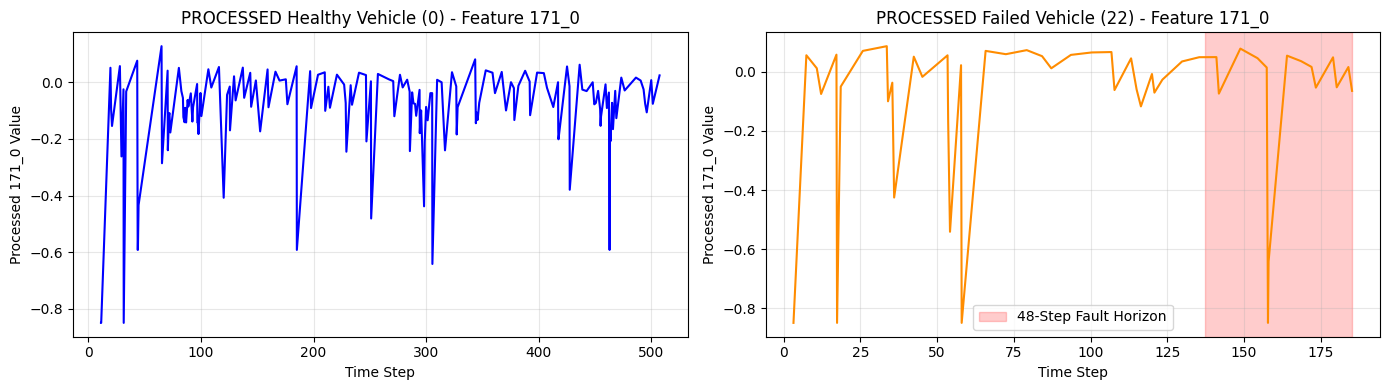

In [24]:
# 1. Grab one healthy and one failed vehicle directly from the processed dataset
healthy_id = train_data[train_data['label'] == 0]['vehicle_id'].unique()[0]
failed_id = train_data[train_data['label'] == 1]['vehicle_id'].unique()[0]

# 2. Filter the processed data for these specific vehicles
healthy_processed = train_data[train_data['vehicle_id'] == healthy_id].sort_values('time_step')
failed_processed = train_data[train_data['vehicle_id'] == failed_id].sort_values('time_step')

# 3. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Healthy Plot
axes[0].plot(healthy_processed['time_step'], healthy_processed['171_0_delta'], color='blue')
axes[0].set_title(f'PROCESSED Healthy Vehicle ({healthy_id}) - Feature 171_0')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Processed 171_0 Value')
axes[0].grid(True, alpha=0.3)

# Failed Plot
axes[1].plot(failed_processed['time_step'], failed_processed['171_0_delta'], color='darkorange')
axes[1].set_title(f'PROCESSED Failed Vehicle ({failed_id}) - Feature 171_0')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Processed 171_0 Value')
axes[1].grid(True, alpha=0.3)

# Highlight the 24-step horizon on the failed vehicle
last_timestep = failed_processed['time_step'].max()
axes[1].axvspan(last_timestep - 48, last_timestep, color='red', alpha=0.2, label='48-Step Fault Horizon')
axes[1].legend()

plt.tight_layout()
plt.show()

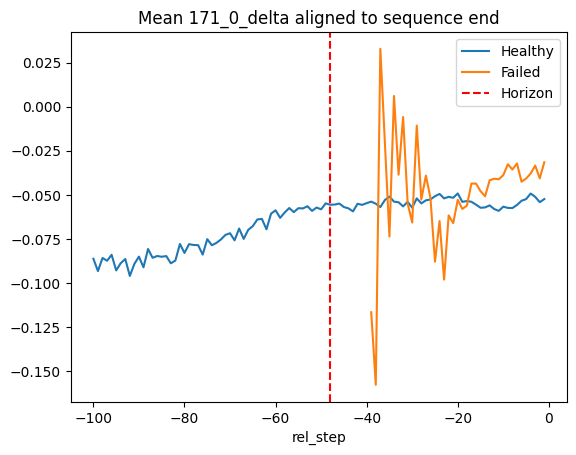

In [25]:
# Align sequences to end, compute mean per class
def plot_class_mean(df, feature, horizon=48, n_steps=100):
    records = []
    for vid, grp in df.groupby('vehicle_id'):
        grp = grp.sort_values('time_step').tail(n_steps)
        grp = grp.reset_index(drop=True)
        grp['rel_step'] = grp.index - len(grp)  # negative = steps before end
        records.append(grp[['rel_step', feature, 'label']])
    
    combined = pd.concat(records)
    combined['failed'] = combined['label']
    combined.groupby(['rel_step', 'failed'])[feature].mean().unstack().plot()
    plt.axvline(-horizon, color='red', linestyle='--', label='Horizon boundary')
    plt.title(f'Mean {feature} aligned to sequence end')
    plt.legend(['Healthy', 'Failed', 'Horizon'])
    plt.show()

plot_class_mean(train_data, '171_0_delta')

# Section 4 - Saving and Exporting the Data

In [27]:
import joblib

SAVE_DIR = DATA_DIR / 'Processed Data/'
print('Saving....')
train_data.to_csv(SAVE_DIR / 'train_processed.csv', index=False)
print('Train saved.')

val_data.to_csv(SAVE_DIR / 'val_processed.csv', index=False)
print('Validation saved.')

test_data.to_csv(SAVE_DIR / 'test_processed.csv', index=False)
print('Test saved.')

val_labels.to_csv(SAVE_DIR / 'val_labels_original.csv', index=False)
print('Validation labels saved.')

test_labels.to_csv(SAVE_DIR / 'test_labels_original.csv', index=False)
print('Test labels saved.')

joblib.dump(scaler, SAVE_DIR / 'scaler.joblib')
joblib.dump({
    'scalable_cols': scalable_cols,
    'degenerate_cols': degenerate_cols,
    'degenerate_medians': medians[degenerate_cols].to_dict(),
}, SAVE_DIR / 'scaler_meta.joblib')

print('Done!')

Saving....
Train saved.
Validation saved.
Test saved.
Validation labels saved.
Test labels saved.
Done!
